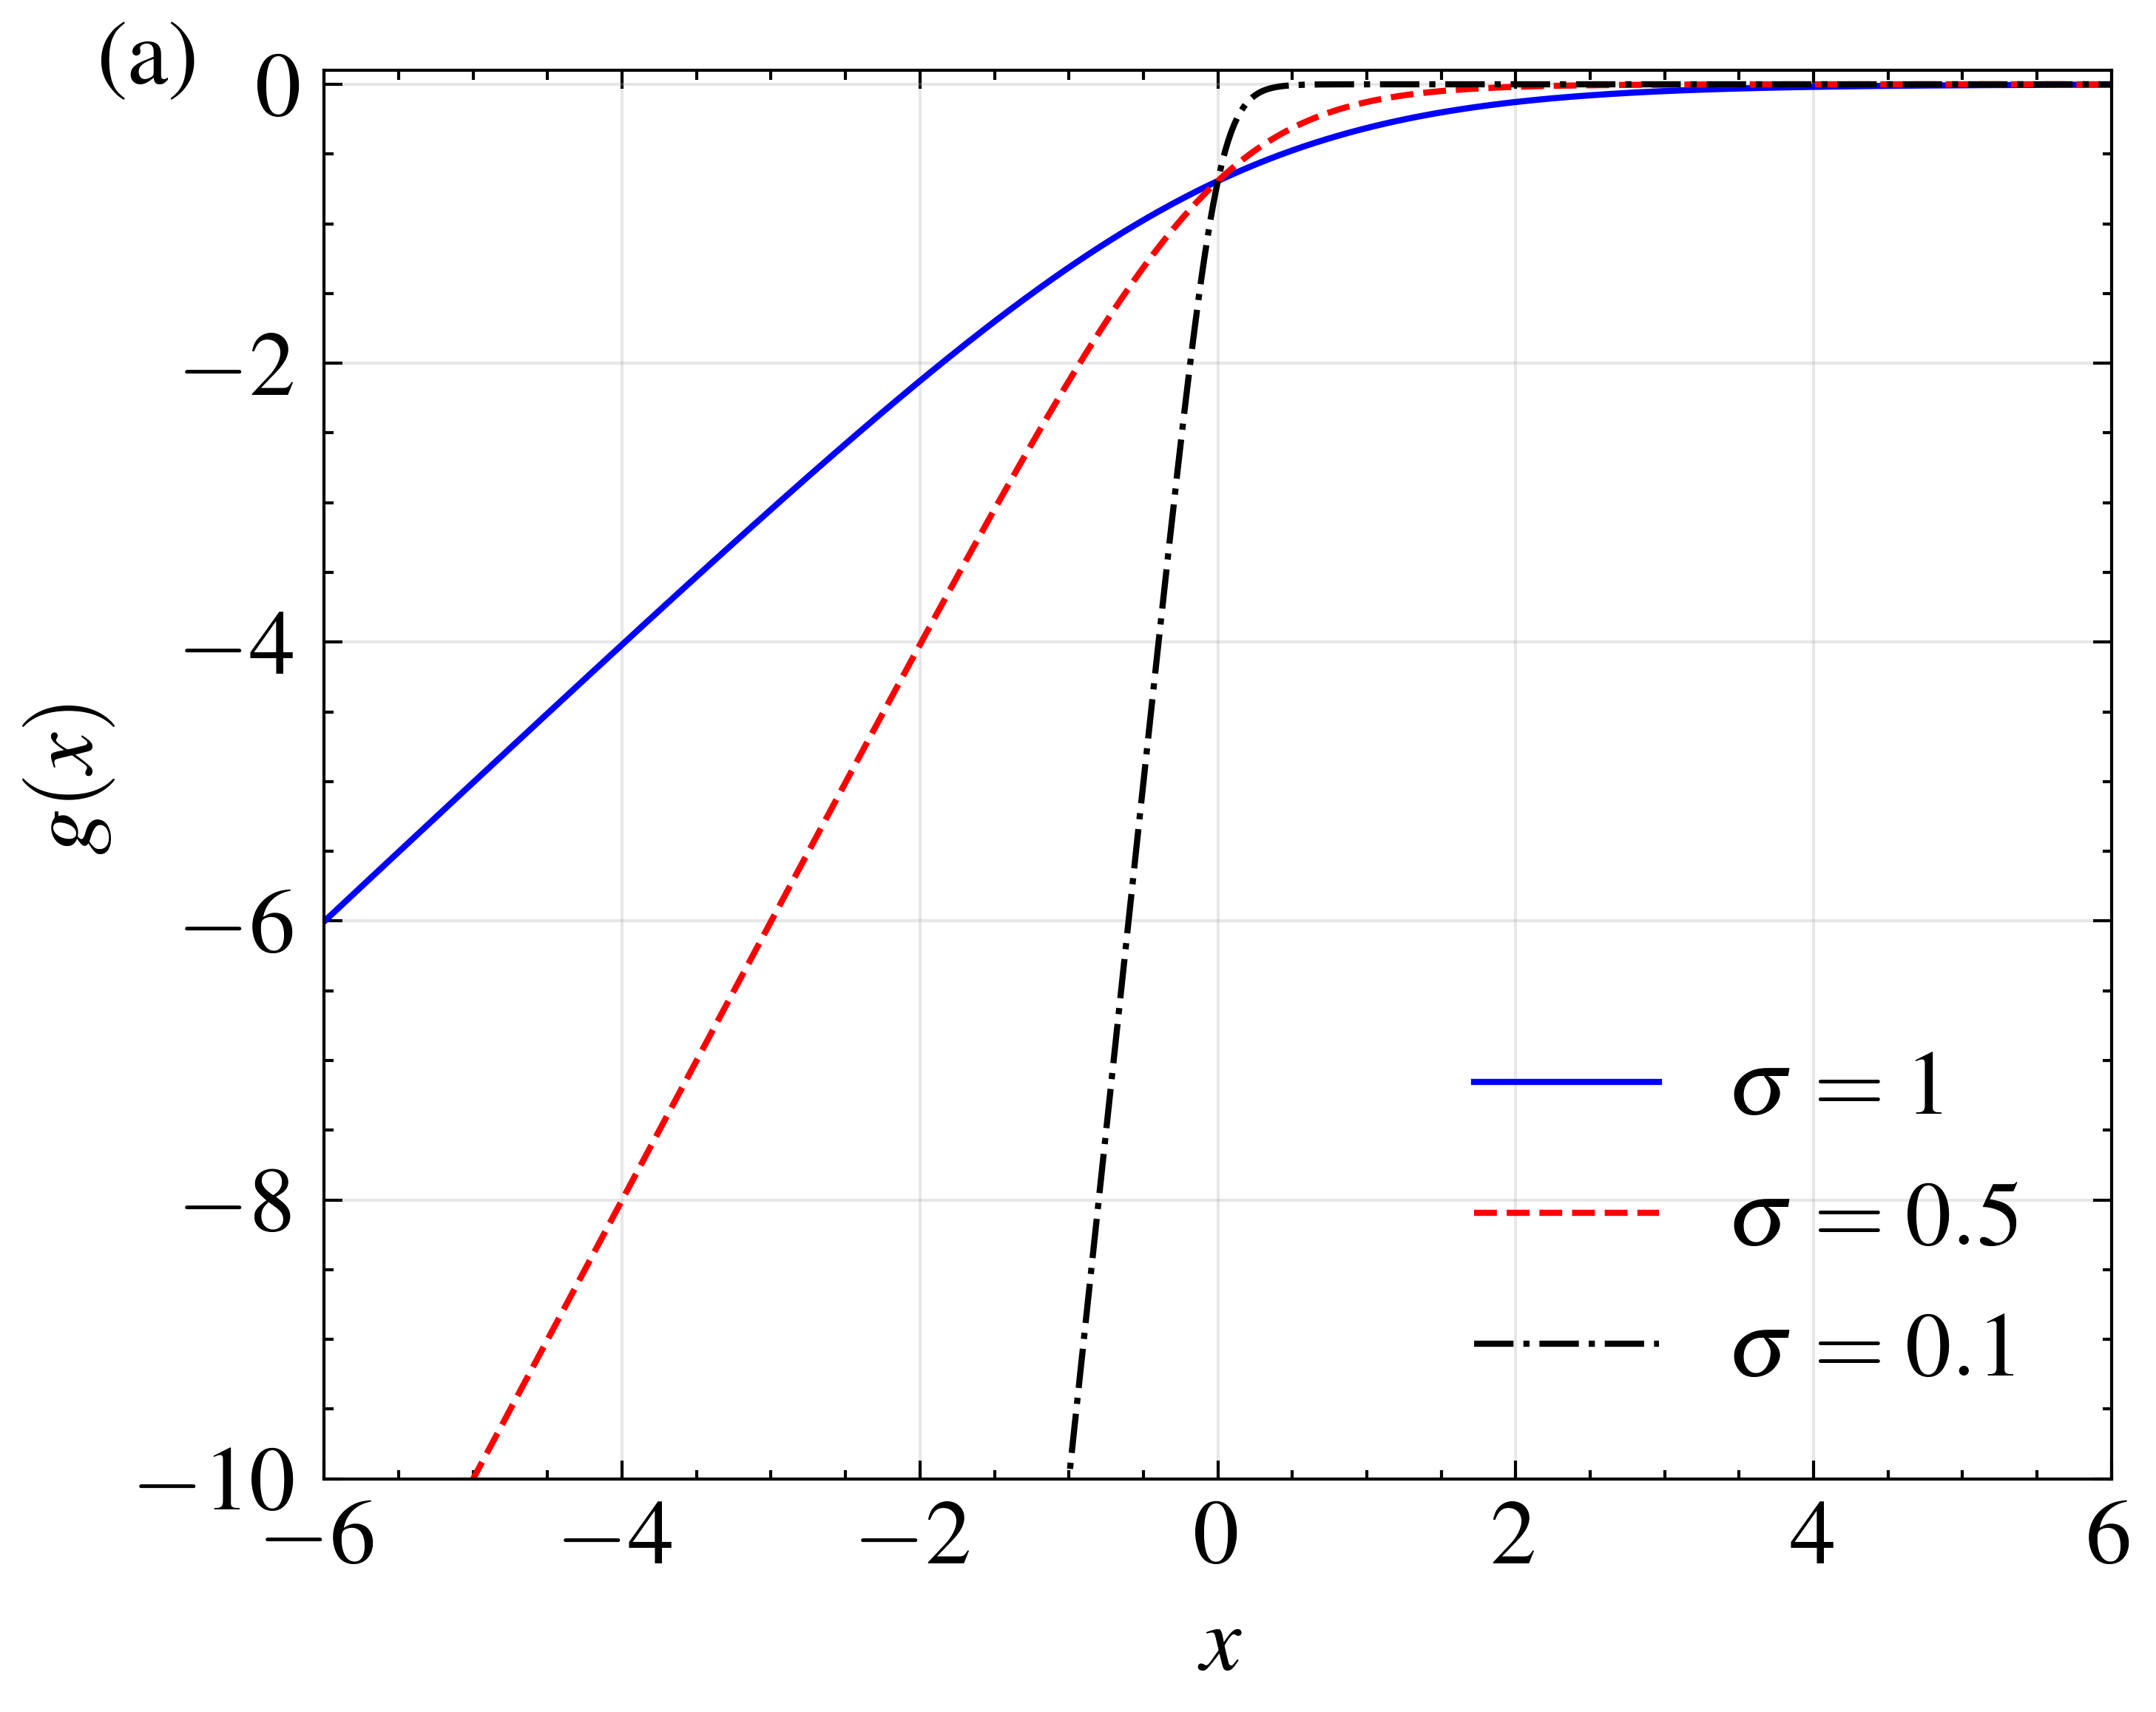

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


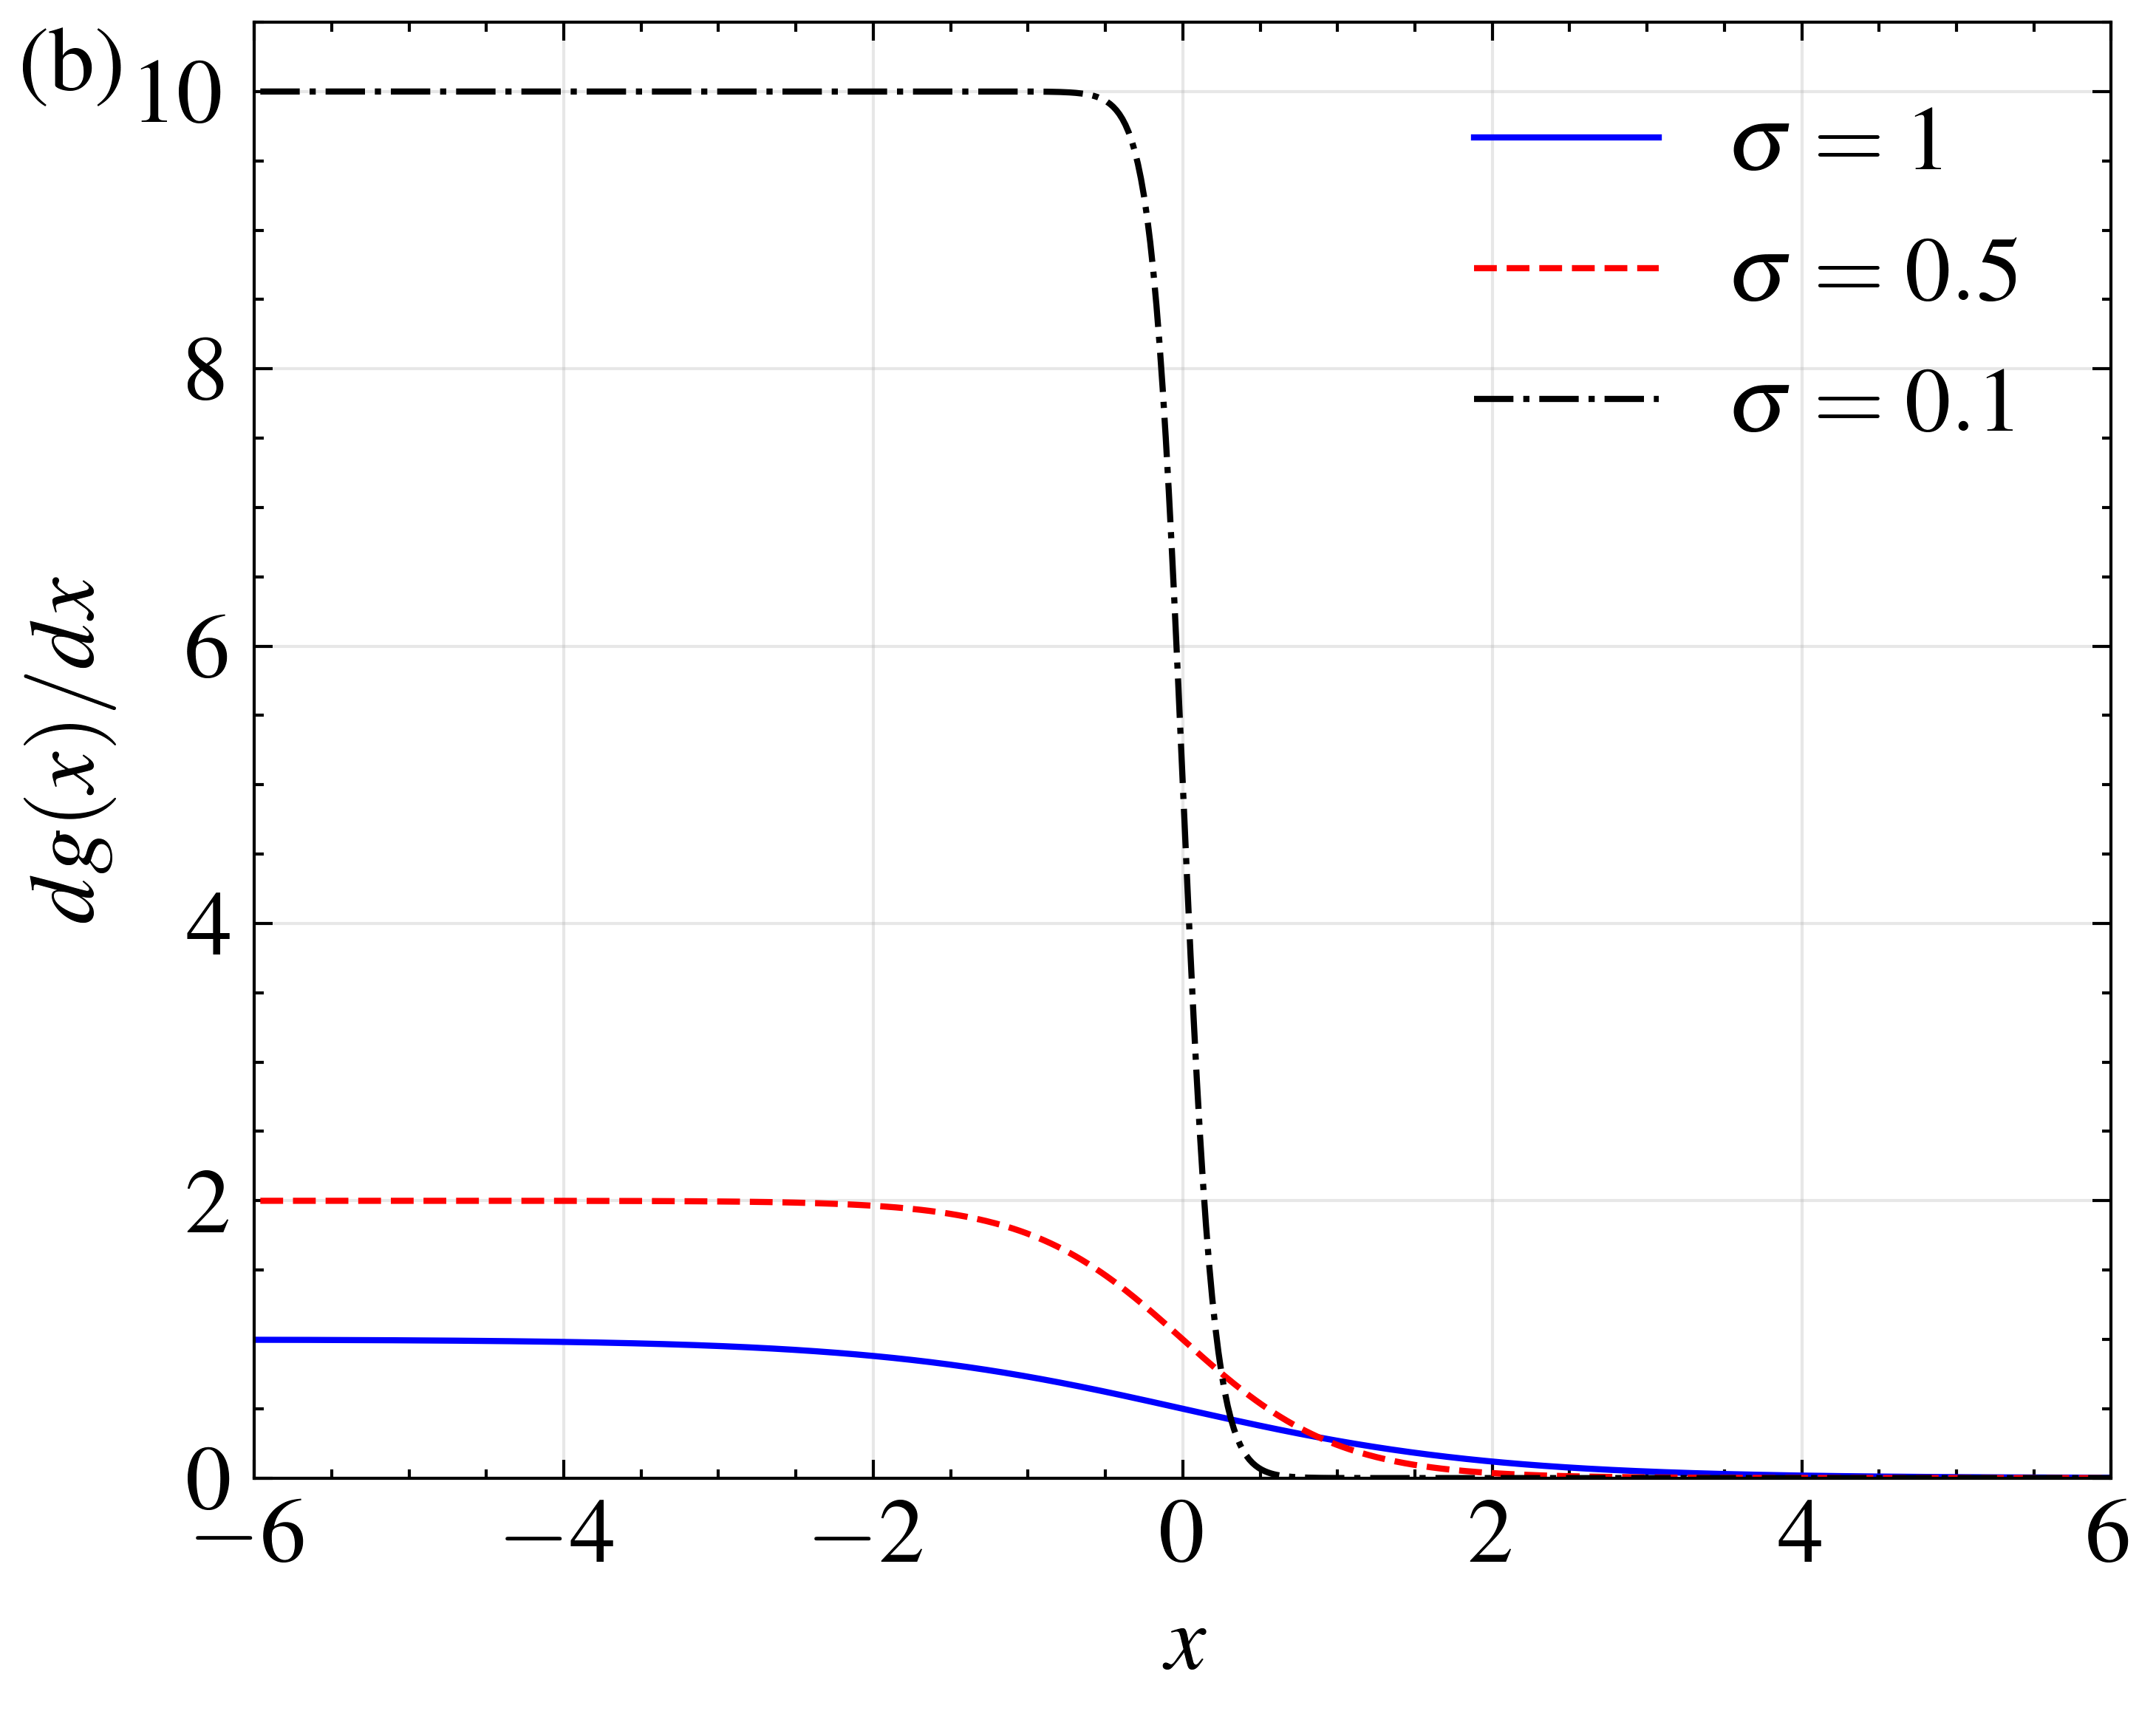

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [19]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots
import torch

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 正常显示负号

plt.rcParams['text.usetex'] = True
plt.style.use(['science', 'ieee'])

def logistic_cdf(u, sigma):
    return 1.0 / (1.0 + torch.exp(-u / sigma))

def measuring_function(u, sigma):
    F_eta = logistic_cdf(u, sigma)
    return torch.log(F_eta)

def gradmeasuring_function(u, sigma):
    return torch.exp(-u / sigma) / (1.0 + torch.exp(-u / sigma)) / sigma 
    
u = torch.linspace(-10, 10, 1000)
g_u1 = measuring_function(u, 1)
g_u05 = measuring_function(u, 0.5)
g_u01 = measuring_function(u, 0.1)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(u.numpy(), g_u1.numpy(), label=r'$\sigma=1$', color='blue', linewidth=1)
ax.plot(u.numpy(), g_u05.numpy(), label=r'$\sigma=0.5$', color='red', linewidth=1, linestyle='--')
ax.plot(u.numpy(), g_u01.numpy(), label=r'$\sigma=0.1$', color='black', linewidth=1, linestyle='-.',)
ax.set_xlabel(r'$x$', fontsize=15)
ax.set_ylabel(r'$g(x)$', fontsize=15)
ax.set_xlim(-6, 6)
ax.set_ylim(-10, 0.1)
ax.tick_params(labelsize=15)
ax.grid(True, alpha=0.3)

ax.text(-7.5, 0, '(a)',fontdict={'size': 15, 'color':  'black'})
ax.legend(loc='lower right', fontsize=15)
plt.tight_layout()
plt.show()
fig.savefig('D:/PRE2025/Fig1a.eps', dpi=800)


grad_g1 = gradmeasuring_function(u, 1)
grad_g05 = gradmeasuring_function(u, 0.5)
grad_g01 = gradmeasuring_function(u, 0.1)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(u.numpy(), grad_g1.numpy(), label=r'$\sigma=1$', color='blue', linewidth=1)
ax.plot(u.numpy(), grad_g05.numpy(), label=r'$\sigma=0.5$', color='red', linewidth=1, linestyle='--')
ax.plot(u.numpy(), grad_g01.numpy(), label=r'$\sigma=0.1$', color='black', linewidth=1, linestyle='-.',)
ax.set_xlabel(r'$x$', fontsize=15)
ax.set_ylabel(r'$dg(x)/dx$', fontsize=15)
ax.set_xlim(-6, 6)
ax.set_ylim(0, 10.5)
ax.tick_params(labelsize=15)
ax.grid(True, alpha=0.3)

ax.text(-7.5, 10, '(b)',fontdict={'size': 15, 'color':  'black'})
ax.legend(loc='upper right', fontsize=15)
plt.tight_layout()
plt.show()
fig.savefig('D:/PRE2025/Fig1b.eps', dpi=800)

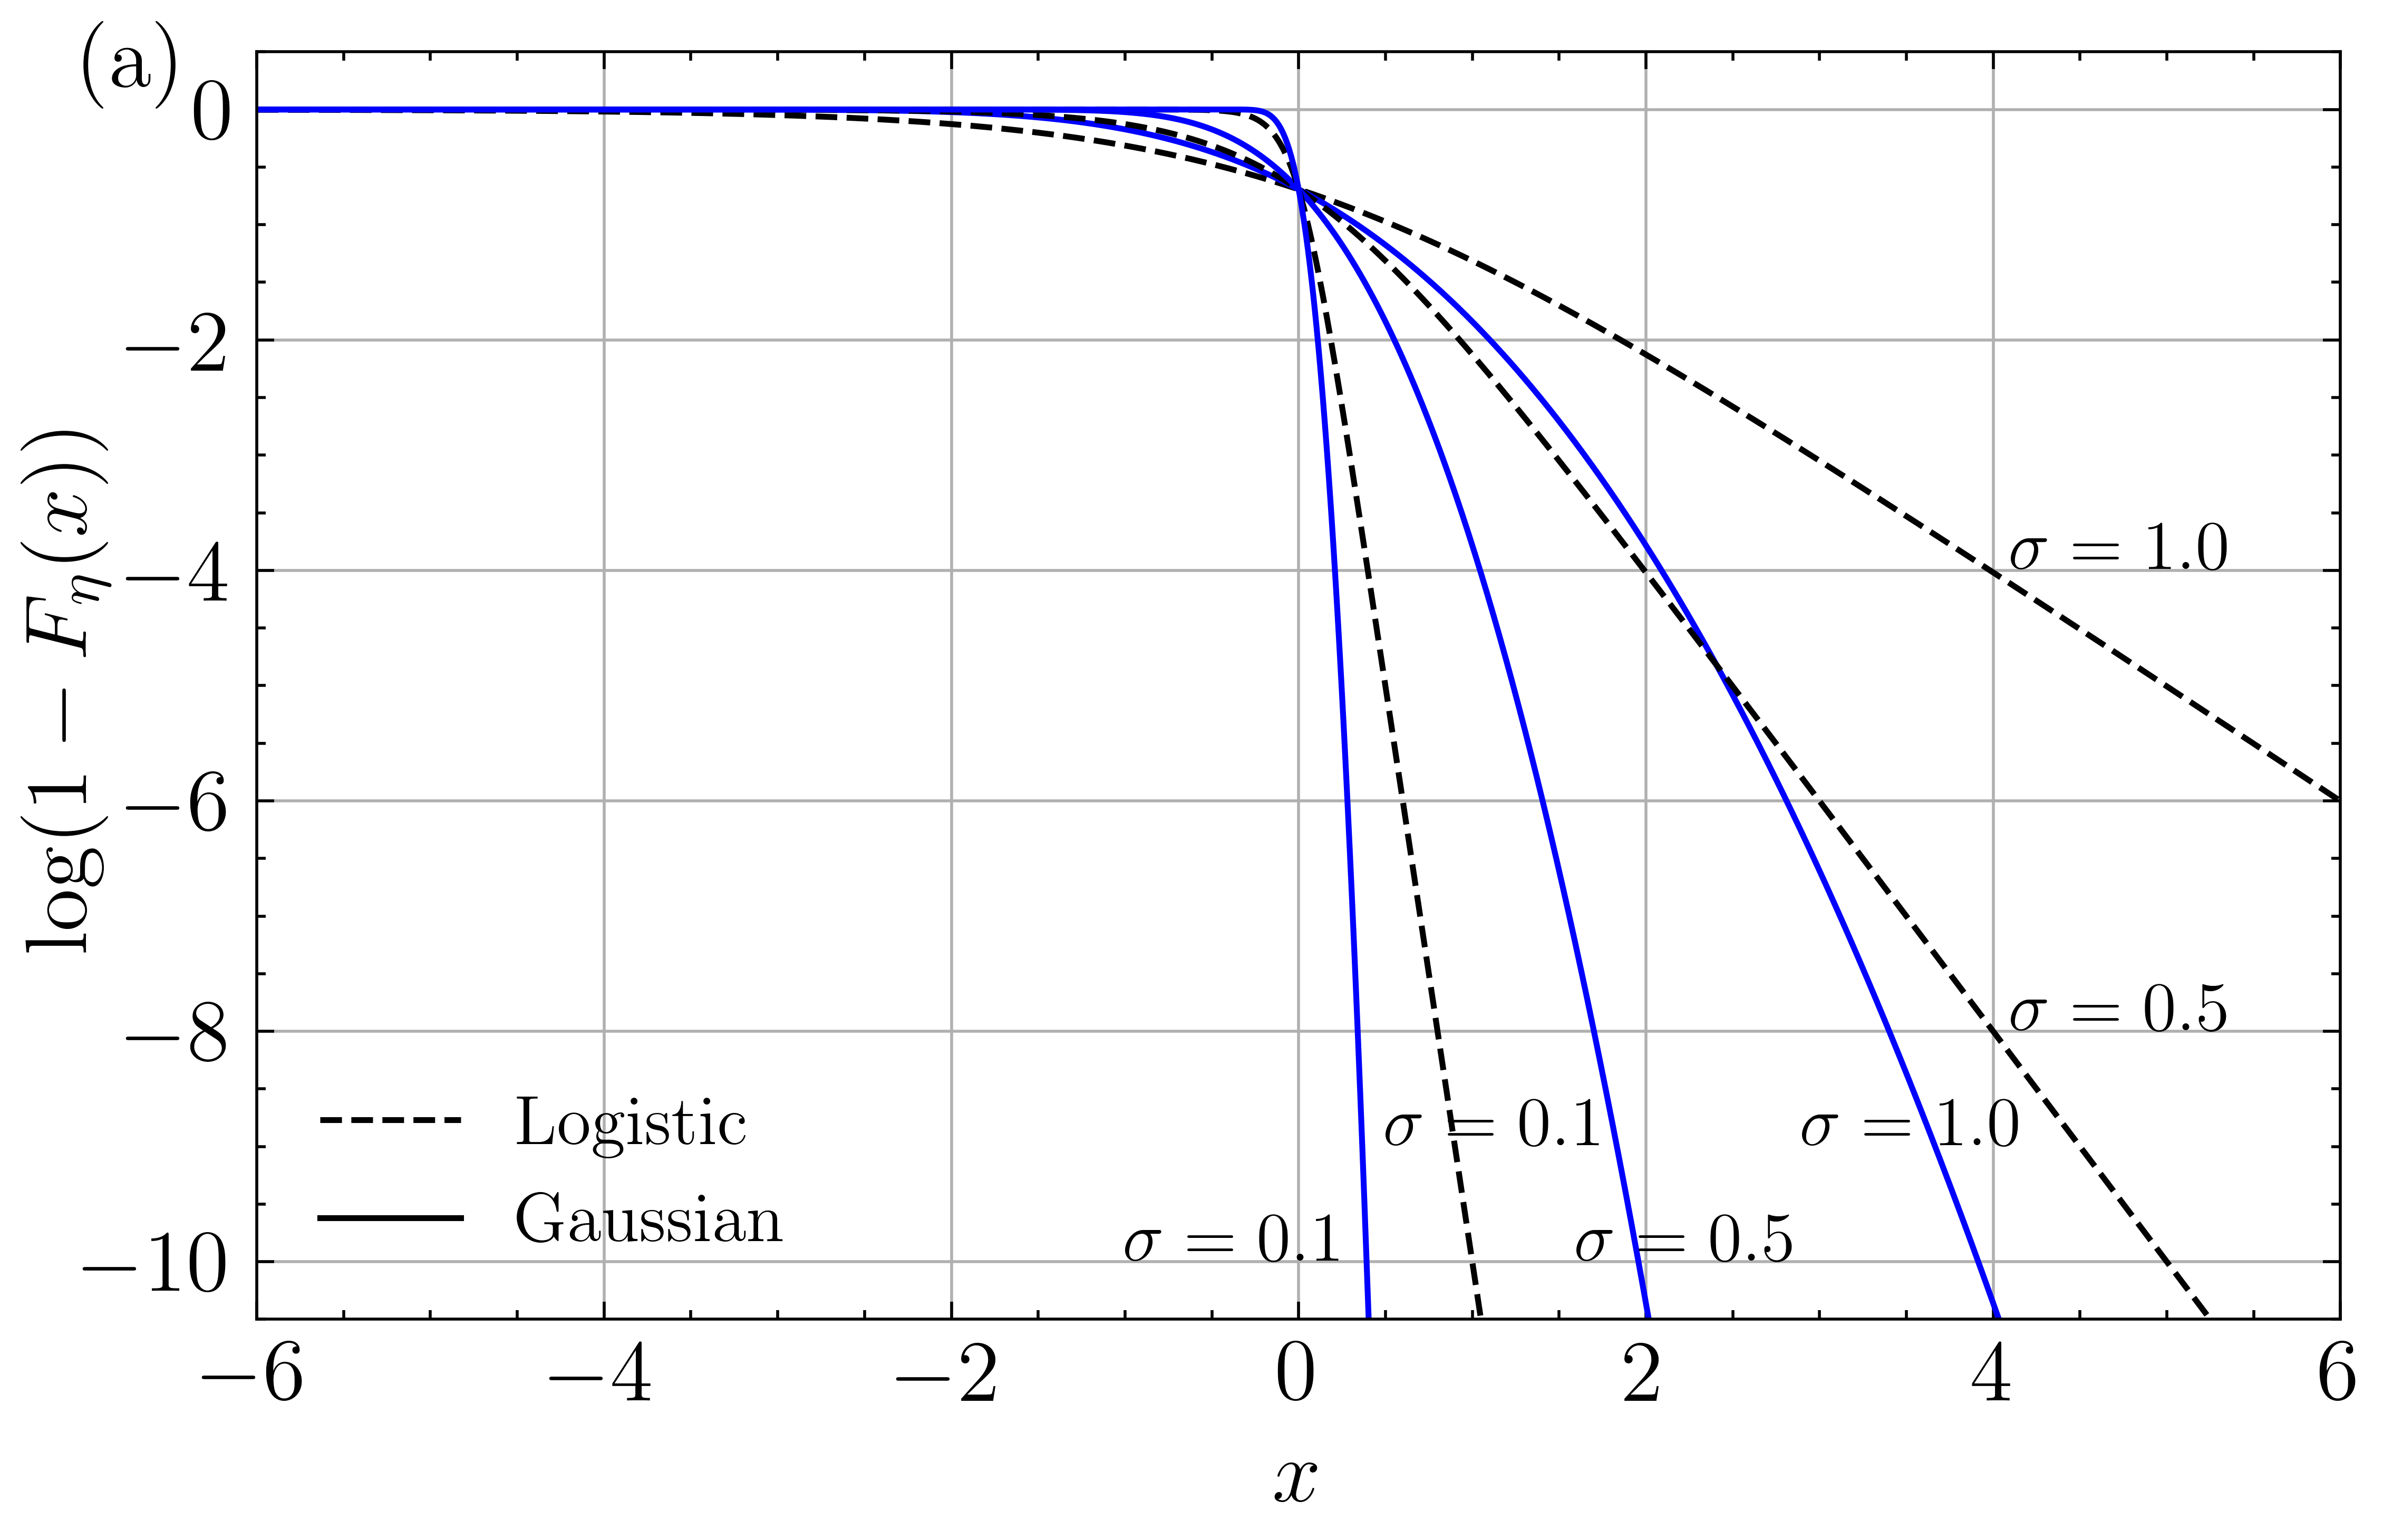

In [28]:
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import math
import scienceplots
from matplotlib.lines import Line2D

# 设置样式与字体
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams.update({
    'font.size': 15,
    'figure.dpi': 800,
    'axes.unicode_minus': False
})

# 使用 float64 以防止数值震荡
dtype = torch.float64
u = torch.linspace(-6, 6, 1000, dtype=dtype)

# 函数定义
def log1m_logistic_cdf(u, sigma):
    return torch.log1p(-1 / (1 + torch.exp(-u / sigma)))

def log1m_gaussian_cdf(u, sigma):
    cdf = 0.5 + 0.5 * torch.erf(u / (math.sqrt(2) * sigma))
    return torch.log(torch.clamp(1.0 - cdf, min=1e-12))  # 防止 log(0)

# sigma 和颜色设置
sigmas = [1.0, 0.5, 0.1]
colors = ['black', 'gray', 'lightgray']

# 创建图
fig, ax = plt.subplots(figsize=(6.0, 4.0))

for sigma, color in zip(sigmas, colors):
    y_logistic = log1m_logistic_cdf(u, sigma)
    y_gaussian = log1m_gaussian_cdf(u, sigma)

    # Logistic：虚线
    ax.plot(u, y_logistic, linestyle='--', color='black')
    # Gaussian：实线
    ax.plot(u, y_gaussian, linestyle='-', color='blue')

# 手动标注 sigma
ax.text(4.1, -4, r'$\sigma=1.0$', fontsize=12)
ax.text(4.1, -8, r'$\sigma=0.5$', fontsize=12)
ax.text(0.5, -9, r'$\sigma=0.1$', fontsize=12)
ax.text(2.9, -9, r'$\sigma=1.0$', fontsize=12)
ax.text(1.6, -10, r'$\sigma=0.5$', fontsize=12)
ax.text(-1, -10, r'$\sigma=0.1$', fontsize=12)
# 坐标轴标签
ax.set_xlabel(r'$x$', fontsize=15)
ax.set_ylabel(r'$\log(1 - F_\eta(x))$', fontsize=15, labelpad=-5)

# y轴范围
ax.set_ylim(-10.5, 0.5)
ax.set_xlim(-6, 6)
ax.grid(True)

# 自定义 legend：线型表示分布类型
custom_lines = [
    Line2D([0], [0], color='black', linestyle='--', lw=1),
    Line2D([0], [0], color='black', linestyle='-', lw=1)
]
ax.legend(custom_lines, ['Logistic', 'Gaussian'], loc='lower left', fontsize=12)

# 子图标签 (b)
ax.text(-7, 0.2, '(a)', fontsize=15)

# 紧凑布局 & 保存
fig.tight_layout()
fig.savefig('D:/PRE2025/Fig2a.eps', dpi=800, format='eps')  # 自定义路径

plt.show()


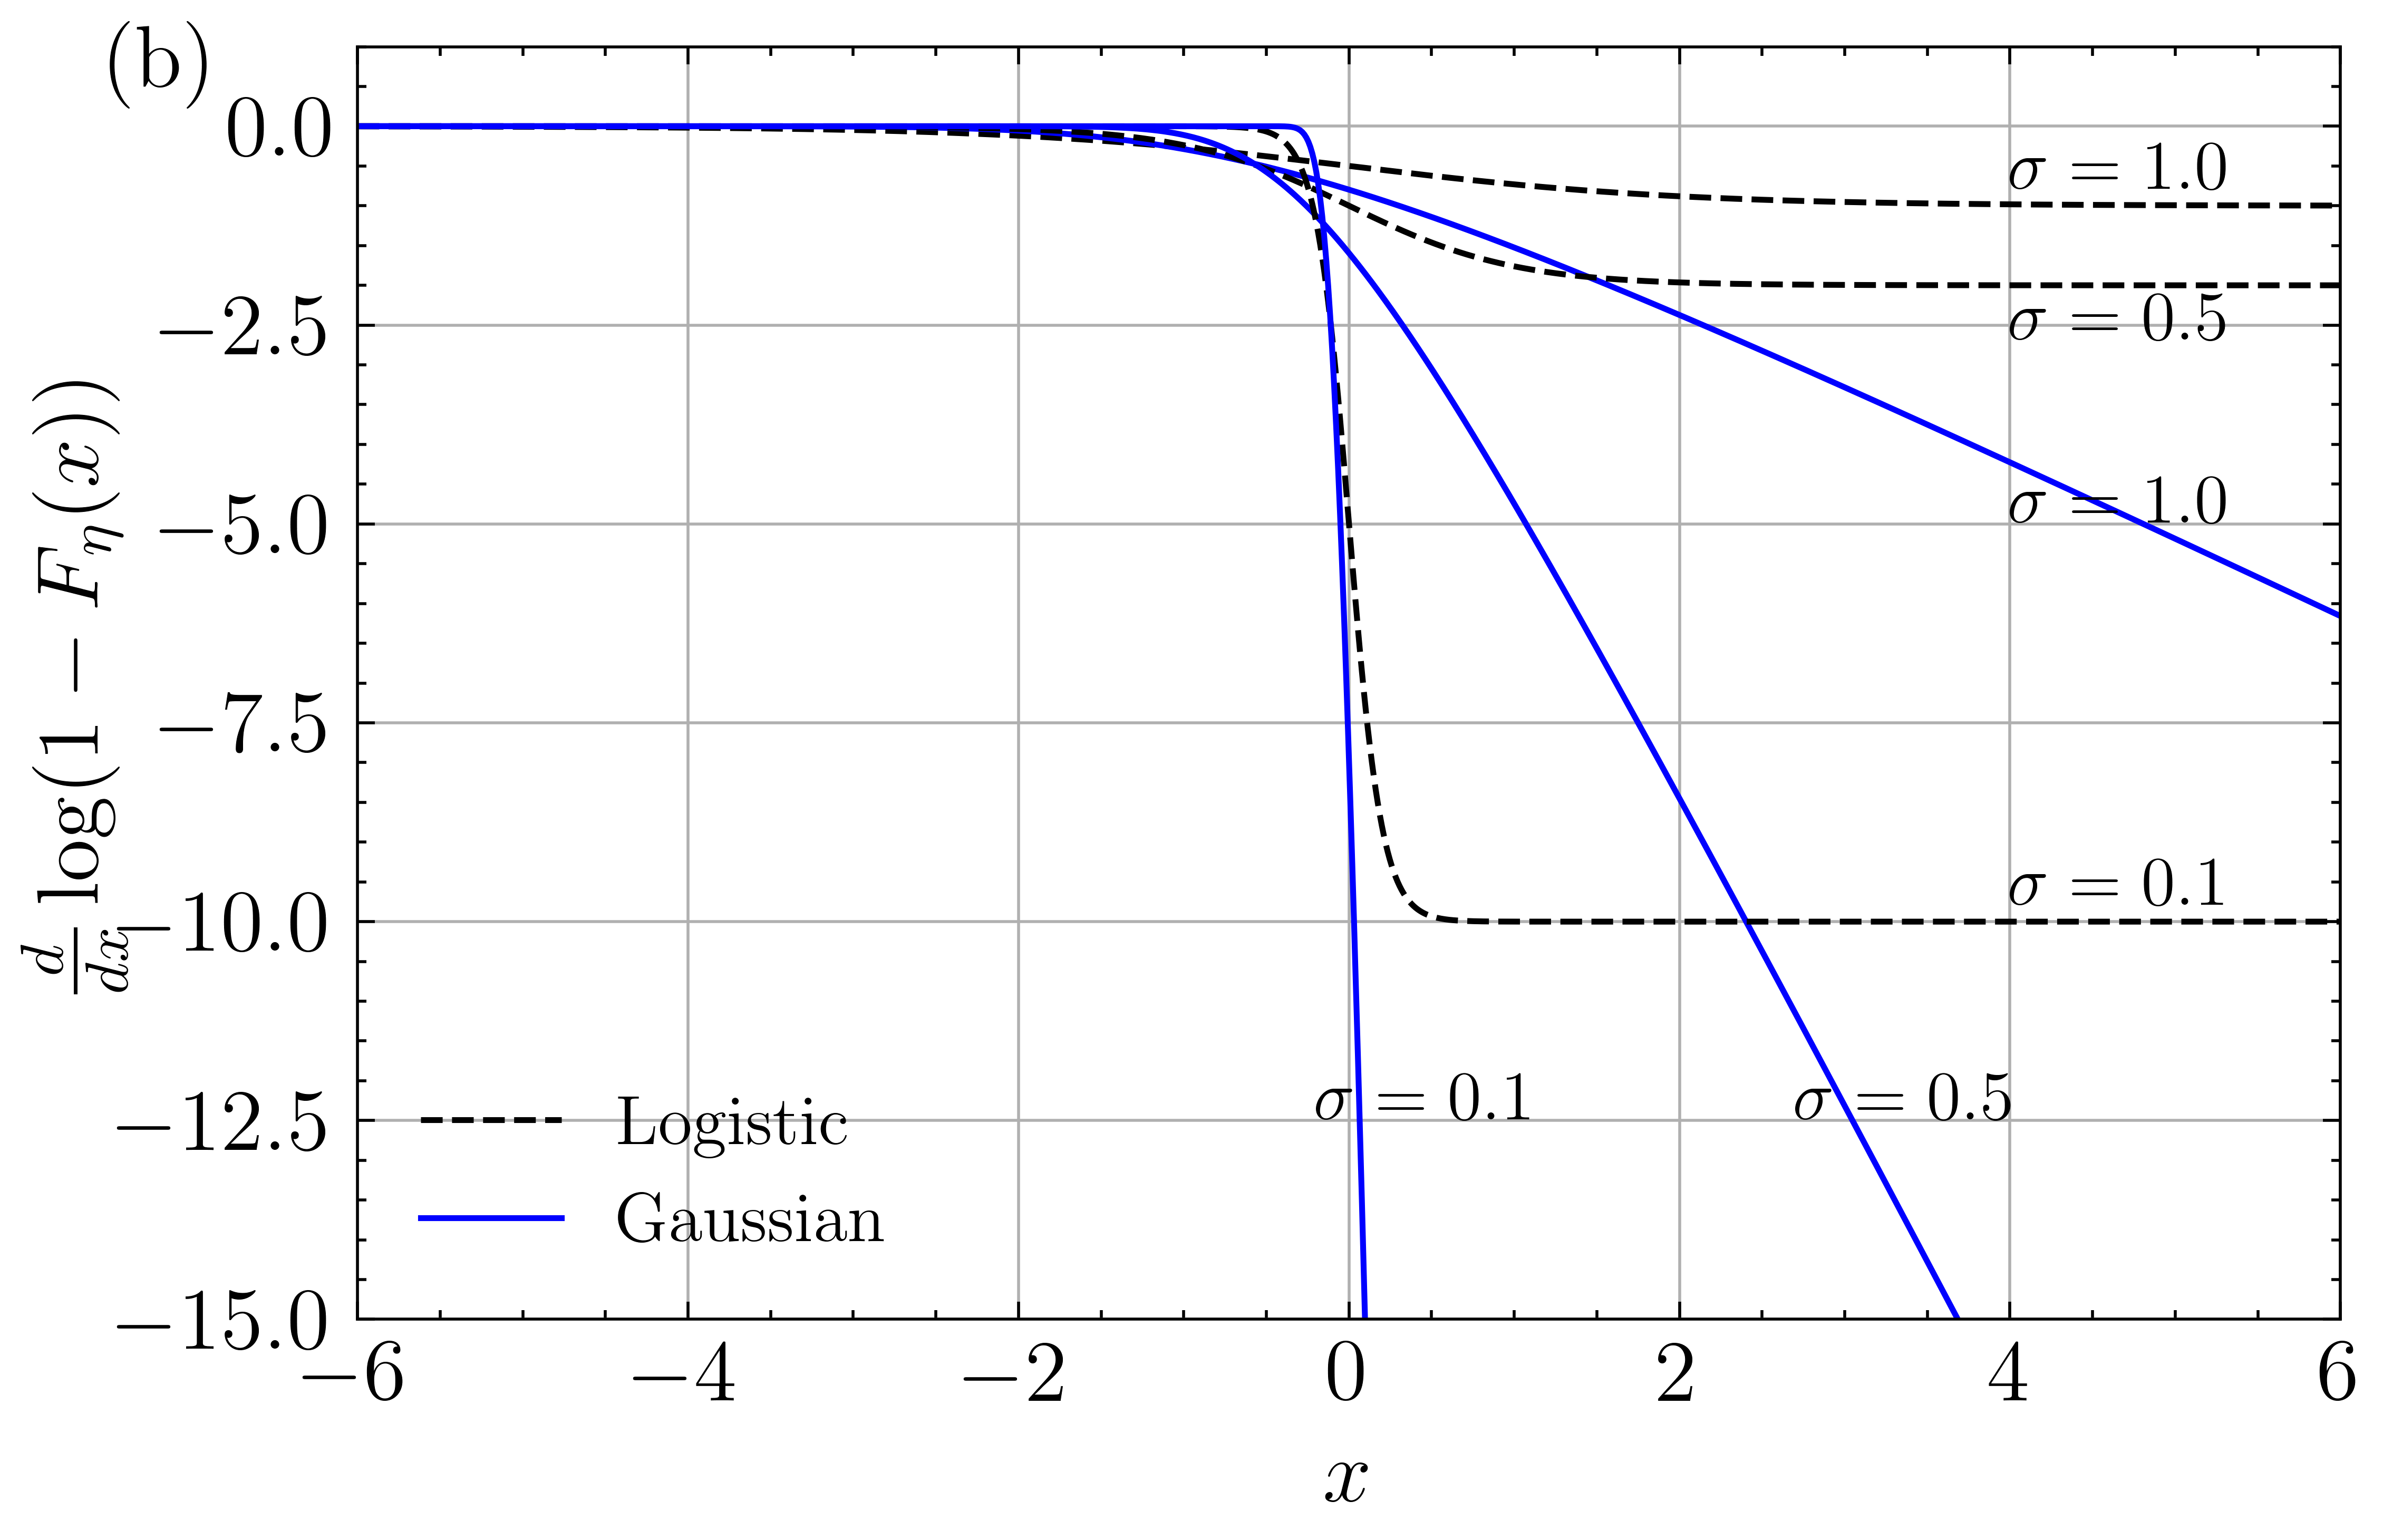

In [45]:
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import math
import scienceplots
from matplotlib.lines import Line2D

# 设置样式
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams.update({
    'font.size': 15,
    'figure.dpi': 800,
    'axes.unicode_minus': False
})

# 设置 u 轴
u = torch.linspace(-6, 6, 1000, dtype=torch.float64)
u.requires_grad_(True)

sigmas = [1.0, 0.5, 0.1]

# Logistic CDF and log(1 - CDF)
def log_one_minus_logistic_cdf(u, sigma):
    return -torch.nn.functional.softplus(u / sigma)  # log(1 - sigmoid(u/sigma))

# Gaussian log(1 - CDF)
def log_one_minus_gaussian_cdf(u, sigma):
    return torch.special.log_ndtr(-u / sigma)

### --------- 图 (b): gradient of log(1 - F_eta(x)) ----------
fig_b, ax_b = plt.subplots(figsize=(6.0, 4.0))

# 创建图例线条
custom_lines = [Line2D([0], [0], color='black', linestyle='--'),
                Line2D([0], [0], color='blue', linestyle='-')]

for sigma in sigmas:
    # Logistic gradient - 黑色虚线
    u_logistic = u.clone().detach().requires_grad_(True)
    log_logistic = log_one_minus_logistic_cdf(u_logistic, sigma)
    grad_log_logistic = torch.autograd.grad(log_logistic.sum(), u_logistic, create_graph=False)[0]
    ax_b.plot(u_logistic.detach(), grad_log_logistic.detach(),
              linestyle='--', color='black',
              label=f'Logistic σ={sigma}' if sigma == sigmas[0] else "")
    


    
    # Gaussian gradient - 蓝色实线
    u_gaussian = u.clone().detach().requires_grad_(True)
    log_gaussian = log_one_minus_gaussian_cdf(u_gaussian, sigma)
    grad_log_gaussian = torch.autograd.grad(log_gaussian.sum(), u_gaussian, create_graph=False)[0]
    ax_b.plot(u_gaussian.detach(), grad_log_gaussian.detach(),
              linestyle='-', color='blue',
              label=f'Gaussian σ={sigma}' if sigma == sigmas[0] else "")



ax_b.set_xlabel(r'$x$', fontsize=15)
ax_b.set_ylabel(r'$\frac{d}{dx} \log(1 - F_\eta(x))$', fontsize=15, labelpad=-2)
ax_b.set_xlim(-6, 6)
ax_b.set_ylim(-15, 1)
ax_b.grid(True)

ax_b.text(4.0, -0.8, r'$\sigma=1.0$', fontsize=12)
ax_b.text(4.0, -2.7, r'$\sigma=0.5$', fontsize=12)
ax_b.text(4.0, -9.8, r'$\sigma=0.1$', fontsize=12)
ax_b.text(4.0, -5, r'$\sigma=1.0$', fontsize=12)
ax_b.text(2.7, -12.5, r'$\sigma=0.5$', fontsize=12)
ax_b.text(-0.2, -12.5, r'$\sigma=0.1$', fontsize=12)

# 修正图例
ax_b.legend(custom_lines, ['Logistic', 'Gaussian'], loc='lower left', fontsize=12)
ax_b.text(-7.5, 0.5, '(b)', fontsize=15)

fig_b.tight_layout()
fig_b.savefig('D:/PRE2025/Fig2b.eps', dpi=800, format='eps')
plt.show()